## A.I. Assignment 5

## Learning Goals

By the end of this lab, you should be able to:
* Get more familiar with tensors in pytorch 
* Create a simple multilayer perceptron model with pytorch
* Visualise the parameters


### Task

Build a fully connected feed forward network that adds two bits. Determine the a propper achitecture for this network (what database you use for this problem? how many layers? how many neurons on each layer? what is the activation function? what is the loss function? etc)

Create at least 3 such networks and compare their performance (how accurate they are?, how farst they are trained to get at 1 accuracy?)

Display for the best one the weights for each layer.


In [26]:
import torch
import torch.nn as nn
from collections import OrderedDict

In [28]:
# your code here
#model1 = nn.Sequential(OrderedDict([
#    ('hidden', nn.
#]))

model1 = nn.Sequential(OrderedDict([
    ('hidden',  nn.Linear(2, 4)),
    ('act1',    nn.ReLU()),
    ('output',  nn.Linear(4, 2)),
    ('act_out', nn.Sigmoid()),
]))

model2 = nn.Sequential(OrderedDict([
    ('hidden1', nn.Linear(2, 8)),
    ('act1',    nn.Sigmoid()),
    ('hidden2', nn.Linear(8, 4)),
    ('act2',    nn.Sigmoid()),
    ('output',  nn.Linear(4, 2)),
    ('act_out', nn.Sigmoid()),
]))

model3 = nn.Sequential(OrderedDict([
    ('hidden1', nn.Linear(2, 16)),
    ('act1',    nn.Tanh()),
    ('hidden2', nn.Linear(16, 8)),
    ('act2',    nn.Tanh()),
    ('hidden3', nn.Linear(8, 4)),
    ('act3',    nn.Tanh()),
    ('output',  nn.Linear(4, 2)),
    ('act_out', nn.Sigmoid()),
]))

In [29]:
print(model1)
print(model2)
print(model3)

Sequential(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (act1): ReLU()
  (output): Linear(in_features=4, out_features=2, bias=True)
  (act_out): Sigmoid()
)
Sequential(
  (hidden1): Linear(in_features=2, out_features=8, bias=True)
  (act1): Sigmoid()
  (hidden2): Linear(in_features=8, out_features=4, bias=True)
  (act2): Sigmoid()
  (output): Linear(in_features=4, out_features=2, bias=True)
  (act_out): Sigmoid()
)
Sequential(
  (hidden1): Linear(in_features=2, out_features=16, bias=True)
  (act1): Tanh()
  (hidden2): Linear(in_features=16, out_features=8, bias=True)
  (act2): Tanh()
  (hidden3): Linear(in_features=8, out_features=4, bias=True)
  (act3): Tanh()
  (output): Linear(in_features=4, out_features=2, bias=True)
  (act_out): Sigmoid()
)


In [30]:
# your code here
#data_in = torch.tensor( ...
data_in = torch.tensor([
    [0.0, 0.0],   #0+0
    [0.0, 1.0],   #0+1
    [1.0, 0.0],   #1+0
    [1.0, 1.0],   #1+1
], dtype=torch.float32)

print(data_in)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [31]:
# your code here
# data_target = torch.tensor( ...
data_target = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    #sum  #carry
], dtype=torch.float32)

print(data_target)

tensor([[0., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.]])


In [32]:
# your code here
# criterion = 
# optimizer =
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model1.parameters(), lr=0.05)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    weight_decay: 0
)


In [33]:
# your code here
# Train the model
import time
def train_model(model, data_in, data_target, lr=0.05, max_epochs=5000):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    acc_history  = []
    epoch_perfect = None

    start = time.time()
    for epoch in range(1, max_epochs + 1):
        #fata
        outputs = model(data_in)
        loss = criterion(outputs, data_target)

        #spate
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds   = (outputs >= 0.5).float()
        correct = (preds == data_target).all(dim=1).sum().item()
        acc     = correct / data_in.shape[0]

        loss_history.append(loss.item())
        acc_history.append(acc)

        if acc == 1.0 and epoch_perfect is None:
            epoch_perfect = epoch

    elapsed = time.time() - start
    return loss_history, acc_history, epoch_perfect, elapsed


results = []
for model, name in zip([model1, model2, model3],
                       ['Model1', 'Model2', 'Model3']):
    torch.manual_seed(42)
    print(f'Training {name}...')
    loss_h, acc_h, ep_perfect, elapsed = train_model(model, data_in, data_target)
    results.append((loss_h, acc_h, ep_perfect, elapsed))

    ep_str = str(ep_perfect) if ep_perfect else 'never'
    print(f'  Final accuracy : {acc_h[-1]:.2f}')
    print(f'  Perfect epoch  : {ep_str}')
    print(f'  Time           : {elapsed:.3f}s')

Training Model1...
  Final accuracy : 1.00
  Perfect epoch  : 49
  Time           : 5.058s
Training Model2...
  Final accuracy : 1.00
  Perfect epoch  : 67
  Time           : 5.400s
Training Model3...
  Final accuracy : 1.00
  Perfect epoch  : 154
  Time           : 6.721s


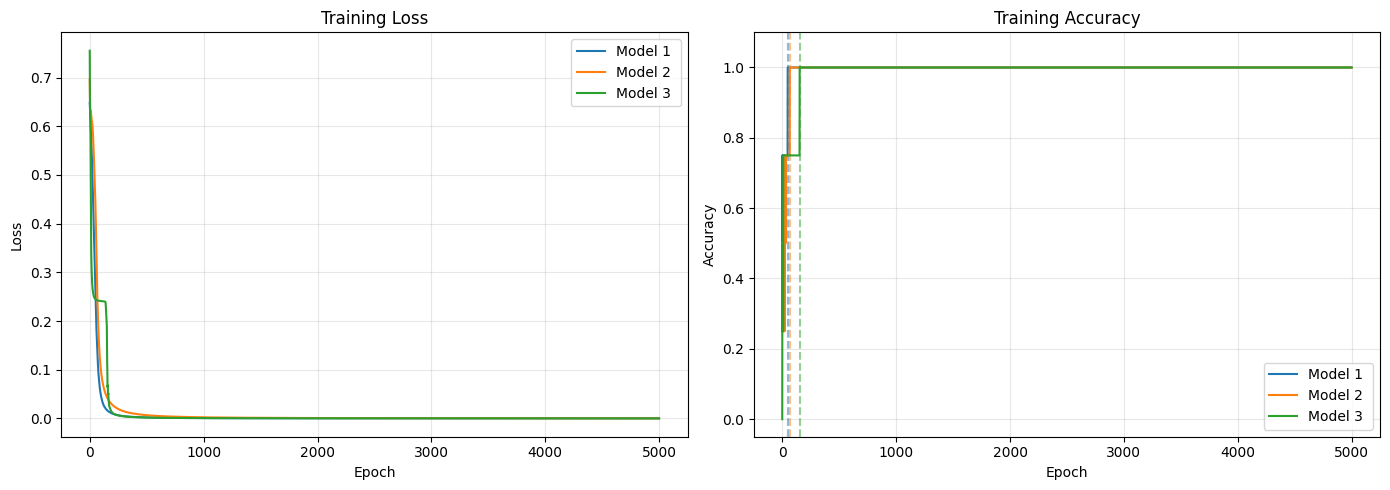

In [34]:
# your code here
# visualize the resuts
import matplotlib.pyplot as plt

colors = ['tab:blue', 'tab:orange', 'tab:green']
names  = ['Model 1 ', 'Model 2 ', 'Model 3 ']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (loss_h, acc_h, ep_perfect, elapsed) in enumerate(results):
    axes[0].plot(loss_h, color=colors[i], label=names[i])
    axes[1].plot(acc_h,  color=colors[i], label=names[i])
    if ep_perfect:
        axes[1].axvline(ep_perfect, color=colors[i], linestyle='--', alpha=0.5)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# your code here
# print model wights
for name, param in model2.named_parameters():
    print(f'Layer: {name}')
    print(param.data)
    print()

Layer: hidden1.weight
tensor([[-3.9842, -3.5474],
        [-2.6071, -3.7703],
        [-3.8243, -3.2174],
        [ 3.8204,  3.8417],
        [ 3.8575,  3.7810],
        [-3.8474, -3.3282],
        [-3.2304, -3.6448],
        [ 3.5826,  3.9911]])

Layer: hidden1.bias
tensor([ 3.9977,  3.6729,  4.1692, -1.9757, -1.9838,  4.4951,  4.4099, -2.0932])

Layer: hidden2.weight
tensor([[ 5.4721,  5.3001,  6.1754, -2.4545, -2.4441,  5.3523,  4.7076, -3.4893],
        [ 3.0745,  1.8575,  2.3938, -4.6871, -3.9578,  1.0537,  1.0313, -4.6047],
        [ 3.0626,  1.9119,  2.0247, -3.9422, -3.8060,  1.5076,  0.6238, -4.6000],
        [ 2.8097,  1.5015,  2.0359, -3.7250, -3.7105,  1.4014,  0.6669, -4.4808]])

Layer: hidden2.bias
tensor([-1.7348, -2.5372, -2.6437, -2.2864])

Layer: output.weight
tensor([[ 18.2187,  -8.3167,  -6.4559,  -6.8541],
        [-18.2594,  -1.0074,  -1.7959,  -2.2650]])

Layer: output.bias
tensor([-8.7034,  8.5909])

